In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
# Load all experiment data
exp_dir = Path("exp2")

# Load summary
summary_df = pd.read_csv(exp_dir / "summary.csv")

# Load detailed history for each run
histories = {}
for run_id in summary_df['run_id']:
    history_path = exp_dir / f"run_{run_id:03d}" / "history.json"
    with open(history_path) as f:
        histories[run_id] = json.load(f)

print(f"Loaded {len(histories)} experiment runs")
summary_df.head()

Loaded 5 experiment runs


,run_id,timestamp,window_size,corr_threshold,num_epoch,learning_rate,batch_size,hidden_dim,out_dim,dropout,embed_l2_reg,normalize_embeddings,best_epoch,best_loss,final_epoch,final_loss,graphs_last_epoch,batches_last_epoch,notes,history_path
0,1,2025-11-25T17:12:12.333491,29,0.8,30,0.001,64,64,32,0.3,0.0001,True,27,0.057457,30,0.057521,48,12393,NaN,exp1/run_001/history.json
1,2,2025-11-25T17:47:36.952572,29,0.8,30,0.001,64,64,32,0.4,0.0001,True,29,0.061007,30,0.061028,48,12393,NaN,exp1/run_002/history.json
2,3,2025-11-25T18:25:13.893132,29,0.8,30,0.001,64,96,32,0.3,0.0001,True,29,0.055845,30,0.055914,48,12393,NaN,exp1/run_003/history.json
3,4,2025-11-25T19:03:32.405414,29,0.8,30,0.001,64,96,32,0.4,0.0001,True,30,0.056906,30,0.056906,48,12393,NaN,exp1/run_004/history.json
4,5,2025-11-25T19:33:37.964510,29,0.8,30,0.001,128,64,32,0.3,0.0001,True,29,0.059291,30,0.059458,48,6210,NaN,exp1/run_005/history.json


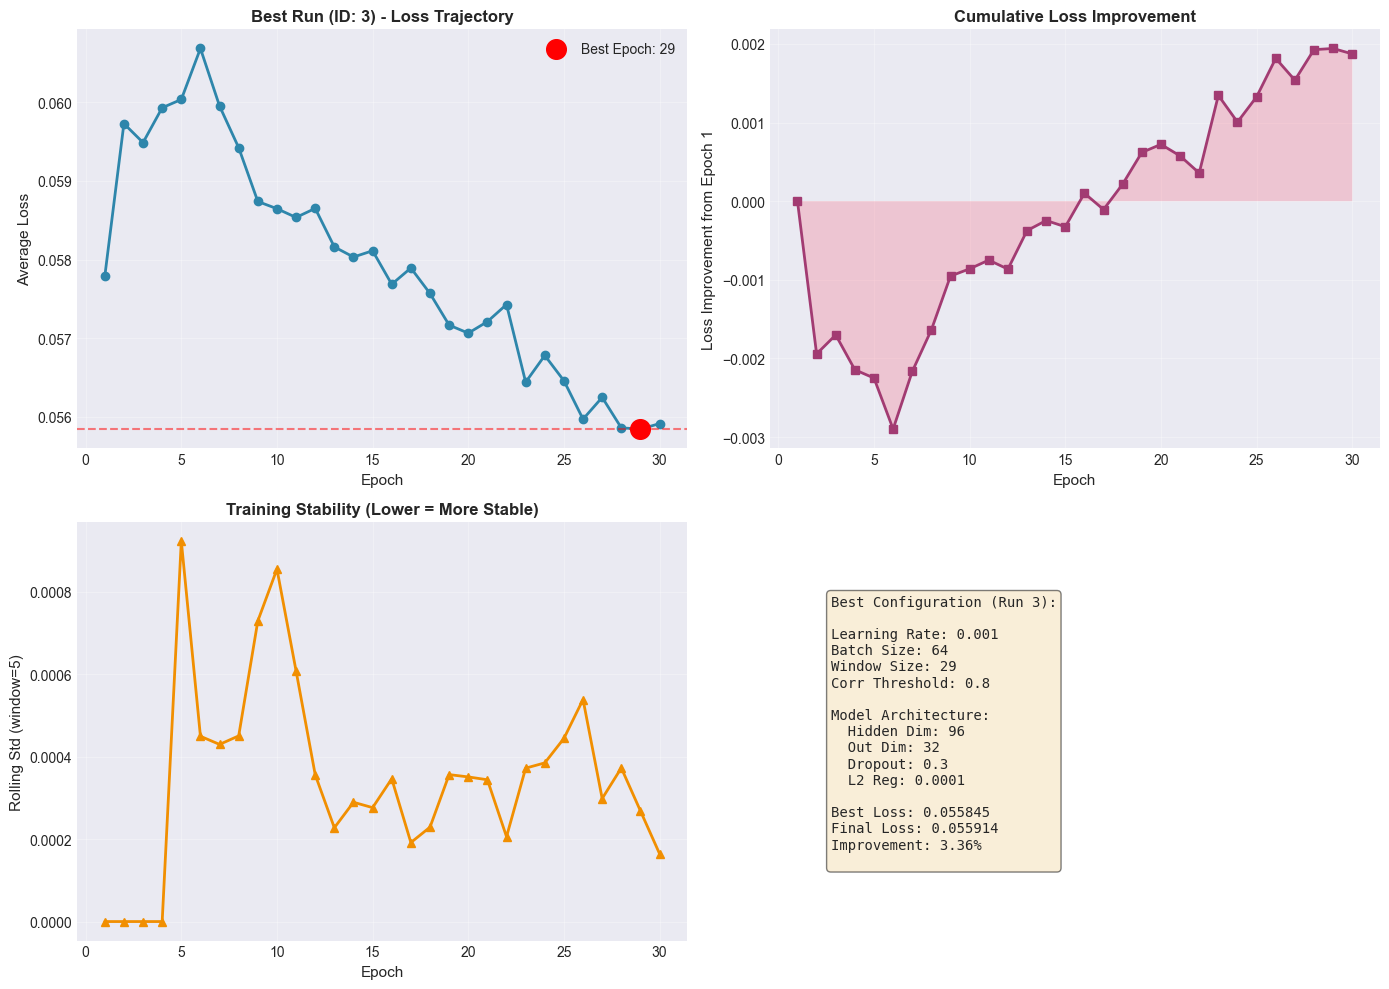

In [4]:
# 2. BEST RUN DETAILED ANALYSIS
best_run_id = summary_df.loc[summary_df['best_loss'].idxmin(), 'run_id']
best_data = histories[best_run_id]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 2a. Loss curve with markers for best epoch
epochs = [h['epoch'] for h in best_data['history']]
losses = [h['avg_loss'] for h in best_data['history']]
best_epoch_idx = np.argmin(losses)

axes[0, 0].plot(epochs, losses, marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0, 0].scatter([epochs[best_epoch_idx]], [losses[best_epoch_idx]], 
                   color='red', s=200, zorder=5, label=f'Best Epoch: {epochs[best_epoch_idx]}')
axes[0, 0].axhline(y=losses[best_epoch_idx], color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Average Loss', fontsize=11)
axes[0, 0].set_title(f'Best Run (ID: {best_run_id}) - Loss Trajectory', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2b. Loss improvement over time
loss_improvements = [losses[0] - l for l in losses]
axes[0, 1].plot(epochs, loss_improvements, marker='s', linewidth=2, color='#A23B72')
axes[0, 1].fill_between(epochs, 0, loss_improvements, alpha=0.3)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss Improvement from Epoch 1', fontsize=11)
axes[0, 1].set_title('Cumulative Loss Improvement', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 2c. Loss variance (smoothness of training)
window_size = 5
rolling_std = pd.Series(losses).rolling(window=window_size).std().fillna(0)
axes[1, 0].plot(epochs, rolling_std, marker='^', linewidth=2, color='#F18F01')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel(f'Rolling Std (window={window_size})', fontsize=11)
axes[1, 0].set_title('Training Stability (Lower = More Stable)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 2d. Configuration summary
config_text = f"""Best Configuration (Run {best_run_id}):

Learning Rate: {best_data['config']['learning_rate']}
Batch Size: {best_data['config']['batch_size']}
Window Size: {best_data['config']['window_size']}
Corr Threshold: {best_data['config']['corr_threshold']}

Model Architecture:
  Hidden Dim: {best_data['config']['model_kwargs']['hidden_dim']}
  Out Dim: {best_data['config']['model_kwargs']['out_dim']}
  Dropout: {best_data['config']['model_kwargs']['dropout']}
  L2 Reg: {best_data['config']['model_kwargs']['embed_l2_reg']}

Best Loss: {losses[best_epoch_idx]:.6f}
Final Loss: {losses[-1]:.6f}
Improvement: {((losses[0] - losses[best_epoch_idx]) / losses[0] * 100):.2f}%
"""
axes[1, 1].text(0.1, 0.5, config_text, fontsize=10, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('best_run_detailed_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

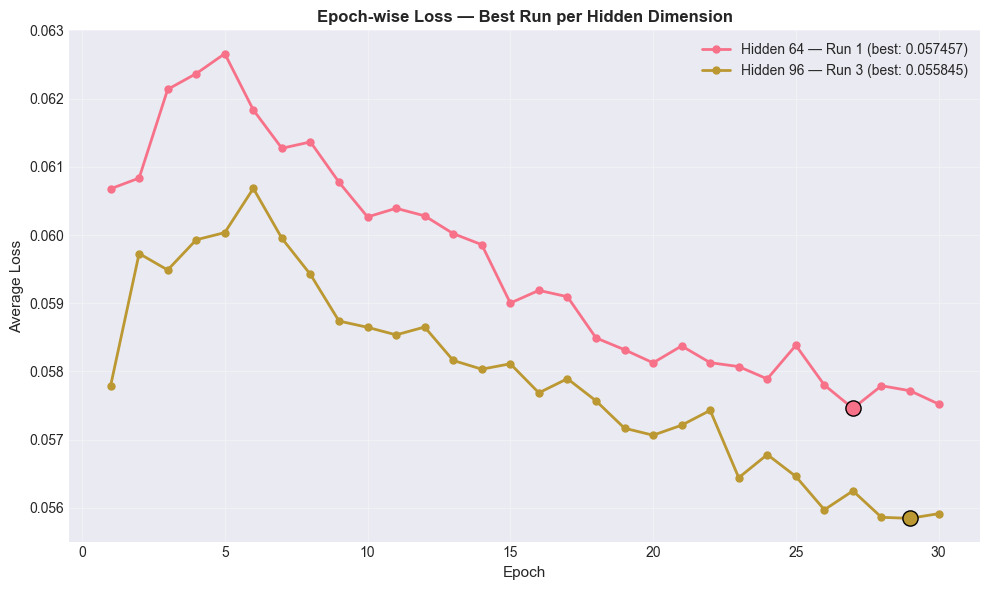

In [12]:
# Compare epoch-wise losses for each hidden_dim: pick best run per hidden_dim and plot together
hidden_dims = sorted(summary_df['hidden_dim'].unique())
best_runs = {}
for hd in hidden_dims:
    subset = summary_df[summary_df['hidden_dim'] == hd]
    best_idx = subset['best_loss'].idxmin()
    best_runs[hd] = int(summary_df.loc[best_idx, 'run_id'])

fig, ax = plt.subplots(figsize=(10, 6))
for hd, run_id in best_runs.items():
    hist = histories[run_id]['history']
    epochs = [h['epoch'] for h in hist]
    losses = [h['avg_loss'] for h in hist]
    best_epoch_i = int(np.argmin(losses))
    ax.plot(epochs, losses, marker='o', linewidth=2, markersize=5,
            label=f'Hidden {hd} — Run {run_id} (best: {min(losses):.6f})')
    ax.scatter(epochs[best_epoch_i], losses[best_epoch_i], s=120, zorder=5, edgecolor='k')

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Average Loss', fontsize=11)
ax.set_title('Epoch-wise Loss — Best Run per Hidden Dimension', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hidden_dim_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


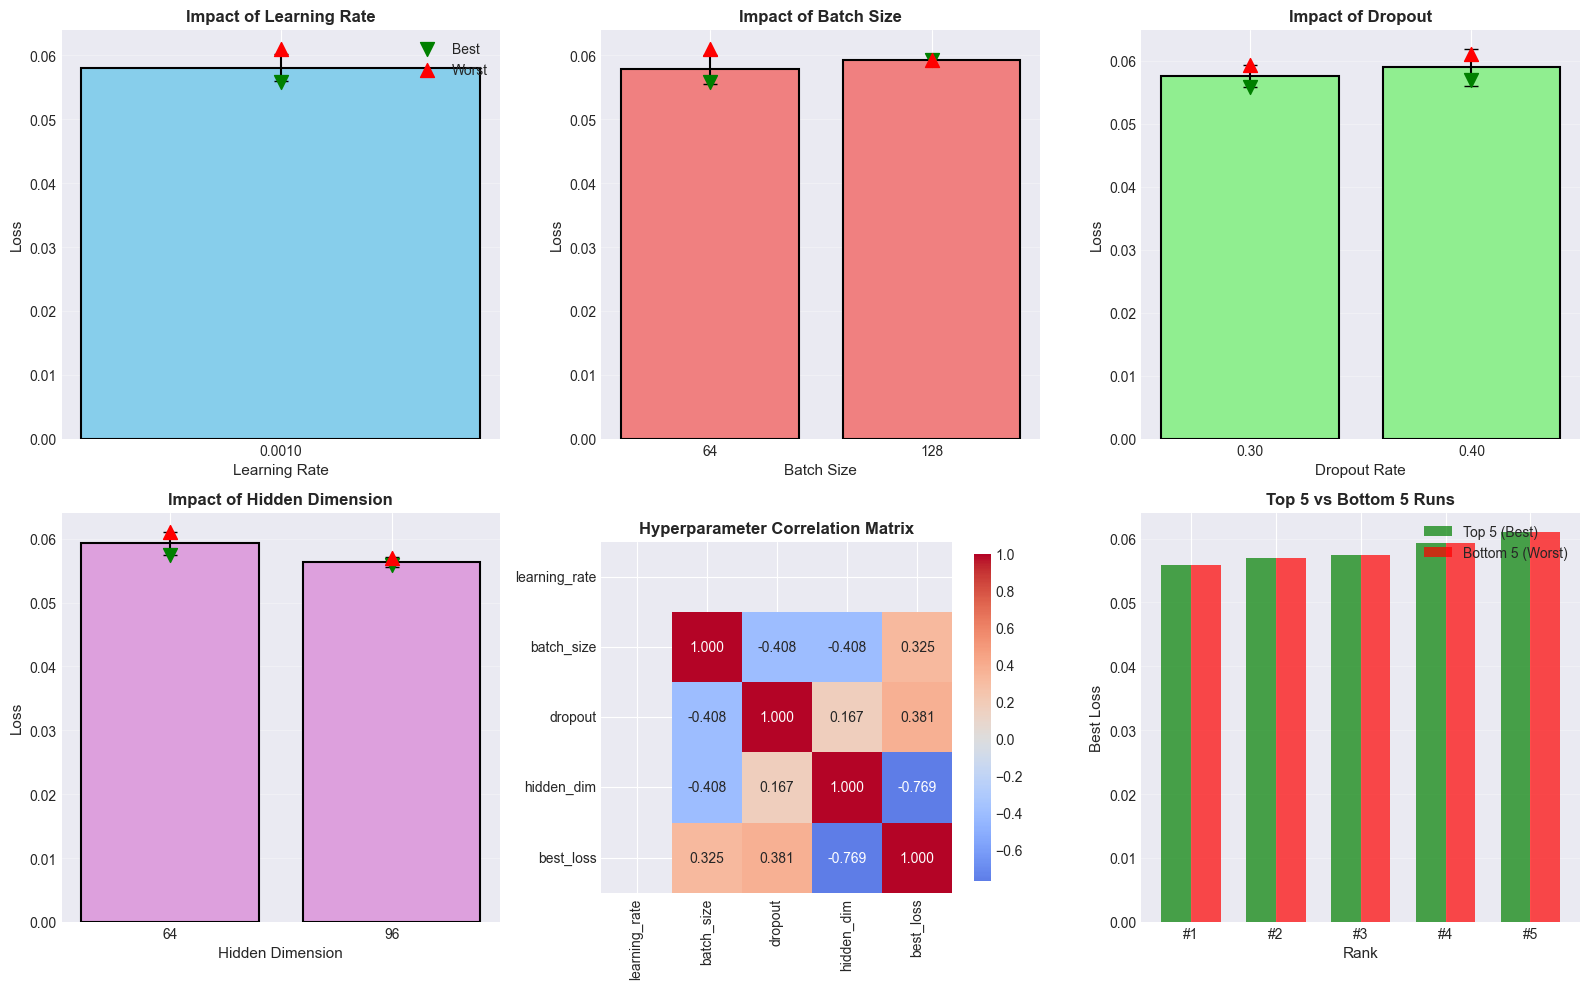

In [5]:
# 3. HYPERPARAMETER IMPACT ANALYSIS
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Extract hyperparameters and final losses
hp_data = []
for run_id, data in histories.items():
    final_loss = data['history'][-1]['avg_loss']
    best_loss = min(h['avg_loss'] for h in data['history'])
    config = data['config']
    
    hp_data.append({
        'run_id': run_id,
        'final_loss': final_loss,
        'best_loss': best_loss,
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'window_size': config.get('window_size', 29),
        'corr_threshold': config.get('corr_threshold', 0.8),
        'hidden_dim': config['model_kwargs']['hidden_dim'],
        'dropout': config['model_kwargs']['dropout']
    })

hp_df = pd.DataFrame(hp_data)

# 3a. Learning Rate Impact
ax = axes[0, 0]
lr_groups = hp_df.groupby('learning_rate')['best_loss'].agg(['mean', 'std', 'min', 'max'])
x_pos = np.arange(len(lr_groups))
ax.bar(x_pos, lr_groups['mean'], yerr=lr_groups['std'], 
       capsize=5, color='skyblue', edgecolor='black', linewidth=1.5)
ax.scatter(x_pos, lr_groups['min'], color='green', s=100, marker='v', label='Best', zorder=5)
ax.scatter(x_pos, lr_groups['max'], color='red', s=100, marker='^', label='Worst', zorder=5)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{lr:.4f}" for lr in lr_groups.index])
ax.set_xlabel('Learning Rate', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Impact of Learning Rate', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 3b. Batch Size Impact
ax = axes[0, 1]
bs_groups = hp_df.groupby('batch_size')['best_loss'].agg(['mean', 'std', 'min', 'max'])
x_pos = np.arange(len(bs_groups))
ax.bar(x_pos, bs_groups['mean'], yerr=bs_groups['std'], 
       capsize=5, color='lightcoral', edgecolor='black', linewidth=1.5)
ax.scatter(x_pos, bs_groups['min'], color='green', s=100, marker='v', zorder=5)
ax.scatter(x_pos, bs_groups['max'], color='red', s=100, marker='^', zorder=5)
ax.set_xticks(x_pos)
ax.set_xticklabels([int(bs) for bs in bs_groups.index])
ax.set_xlabel('Batch Size', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Impact of Batch Size', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 3c. Dropout Impact
ax = axes[0, 2]
dropout_groups = hp_df.groupby('dropout')['best_loss'].agg(['mean', 'std', 'min', 'max'])
x_pos = np.arange(len(dropout_groups))
ax.bar(x_pos, dropout_groups['mean'], yerr=dropout_groups['std'], 
       capsize=5, color='lightgreen', edgecolor='black', linewidth=1.5)
ax.scatter(x_pos, dropout_groups['min'], color='green', s=100, marker='v', zorder=5)
ax.scatter(x_pos, dropout_groups['max'], color='red', s=100, marker='^', zorder=5)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{d:.2f}" for d in dropout_groups.index])
ax.set_xlabel('Dropout Rate', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Impact of Dropout', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 3d. Hidden Dimension Impact
ax = axes[1, 0]
hd_groups = hp_df.groupby('hidden_dim')['best_loss'].agg(['mean', 'std', 'min', 'max'])
x_pos = np.arange(len(hd_groups))
ax.bar(x_pos, hd_groups['mean'], yerr=hd_groups['std'], 
       capsize=5, color='plum', edgecolor='black', linewidth=1.5)
ax.scatter(x_pos, hd_groups['min'], color='green', s=100, marker='v', zorder=5)
ax.scatter(x_pos, hd_groups['max'], color='red', s=100, marker='^', zorder=5)
ax.set_xticks(x_pos)
ax.set_xticklabels([int(hd) for hd in hd_groups.index])
ax.set_xlabel('Hidden Dimension', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Impact of Hidden Dimension', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 3e. Correlation Heatmap
ax = axes[1, 1]
corr_cols = ['learning_rate', 'batch_size', 'dropout', 'hidden_dim', 'best_loss']
corr_matrix = hp_df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Hyperparameter Correlation Matrix', fontsize=12, fontweight='bold')

# 3f. Top 5 vs Bottom 5 Comparison
ax = axes[1, 2]
sorted_hp = hp_df.sort_values('best_loss')
top_5 = sorted_hp.head(5)
bottom_5 = sorted_hp.tail(5)

x = np.arange(5)
width = 0.35

bars1 = ax.bar(x - width/2, top_5['best_loss'].values, width, 
               label='Top 5 (Best)', color='green', alpha=0.7)
bars2 = ax.bar(x + width/2, bottom_5['best_loss'].values, width, 
               label='Bottom 5 (Worst)', color='red', alpha=0.7)

ax.set_xlabel('Rank', fontsize=11)
ax.set_ylabel('Best Loss', fontsize=11)
ax.set_title('Top 5 vs Bottom 5 Runs', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"#{i+1}" for i in range(5)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('hyperparameter_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

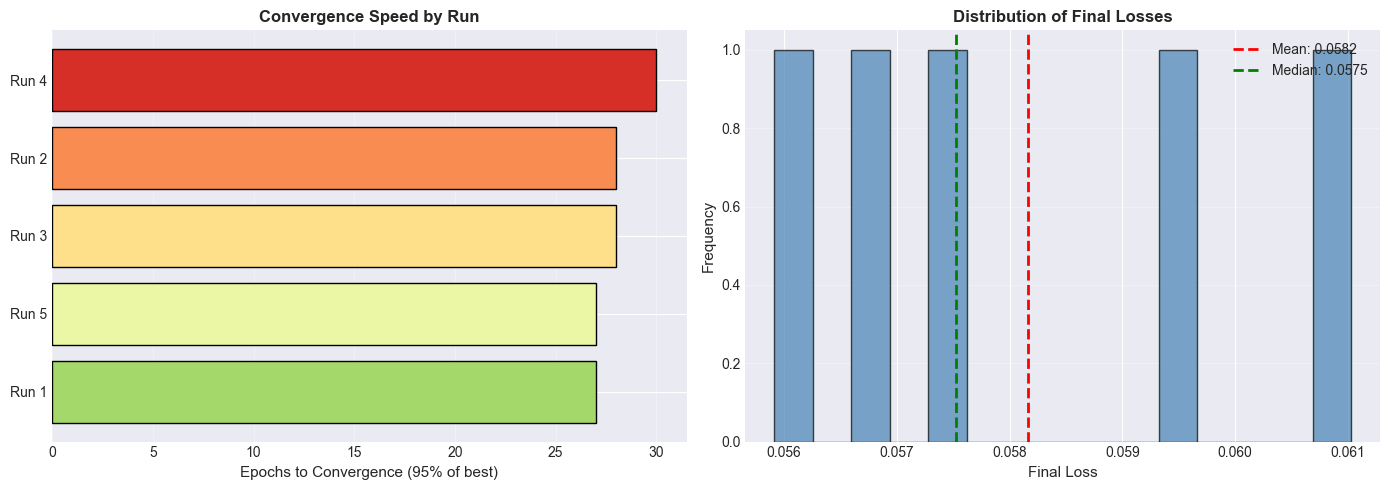

In [6]:
# 4. CONVERGENCE ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4a. Convergence speed (epochs to reach 95% of best loss)
convergence_data = []
for run_id, data in histories.items():
    losses = [h['avg_loss'] for h in data['history']]
    best_loss = min(losses)
    threshold = best_loss + 0.05 * (losses[0] - best_loss)  # 95% of improvement
    
    convergence_epoch = next((i+1 for i, l in enumerate(losses) if l <= threshold), len(losses))
    convergence_data.append({
        'run_id': run_id,
        'convergence_epoch': convergence_epoch,
        'best_loss': best_loss
    })

conv_df = pd.DataFrame(convergence_data).sort_values('convergence_epoch')

ax = axes[0]
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(conv_df)))
bars = ax.barh(range(len(conv_df)), conv_df['convergence_epoch'], color=colors, edgecolor='black')
ax.set_yticks(range(len(conv_df)))
ax.set_yticklabels([f"Run {rid}" for rid in conv_df['run_id']])
ax.set_xlabel('Epochs to Convergence (95% of best)', fontsize=11)
ax.set_title('Convergence Speed by Run', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 4b. Final loss distribution
ax = axes[1]
final_losses = [data['history'][-1]['avg_loss'] for data in histories.values()]
ax.hist(final_losses, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(final_losses), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(final_losses):.4f}')
ax.axvline(np.median(final_losses), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(final_losses):.4f}')
ax.set_xlabel('Final Loss', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Final Losses', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('convergence_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# 5. SUMMARY TABLE
print("="*80)
print("EXPERIMENT SUMMARY")
print("="*80)

summary_stats = hp_df[['best_loss', 'final_loss']].describe()
print("\nLoss Statistics:")
print(summary_stats)

print("\n" + "="*80)
print("TOP 5 CONFIGURATIONS")
print("="*80)
top_5_configs = hp_df.nsmallest(5, 'best_loss')[['run_id', 'learning_rate', 'batch_size', 
                                                    'hidden_dim', 'dropout', 'best_loss']]
print(top_5_configs.to_string(index=False))

print("\n" + "="*80)
print("HYPERPARAMETER RECOMMENDATIONS")
print("="*80)

# Find best value for each hyperparameter
best_lr = hp_df.loc[hp_df['best_loss'].idxmin(), 'learning_rate']
best_bs = hp_df.loc[hp_df['best_loss'].idxmin(), 'batch_size']
best_hd = hp_df.loc[hp_df['best_loss'].idxmin(), 'hidden_dim']
best_dropout = hp_df.loc[hp_df['best_loss'].idxmin(), 'dropout']

recommendations = f"""
Recommended Configuration (based on best performing run):
  - Learning Rate: {best_lr}
  - Batch Size: {int(best_bs)}
  - Hidden Dimension: {int(best_hd)}
  - Dropout: {best_dropout}
  
Expected Performance:
  - Best Loss: {hp_df['best_loss'].min():.6f}
  - Average Loss across runs: {hp_df['best_loss'].mean():.6f} ± {hp_df['best_loss'].std():.6f}
"""
print(recommendations)

EXPERIMENT SUMMARY

Loss Statistics:
       best_loss  final_loss
count   5.000000    5.000000
mean    0.058101    0.058165
std     0.002049    0.002058
min     0.055845    0.055914
25%     0.056906    0.056906
50%     0.057457    0.057521
75%     0.059291    0.059458
max     0.061007    0.061028

TOP 5 CONFIGURATIONS
 run_id  learning_rate  batch_size  hidden_dim  dropout  best_loss
      3          0.001          64          96      0.3   0.055845
      4          0.001          64          96      0.4   0.056906
      1          0.001          64          64      0.3   0.057457
      5          0.001         128          64      0.3   0.059291
      2          0.001          64          64      0.4   0.061007

HYPERPARAMETER RECOMMENDATIONS

Recommended Configuration (based on best performing run):
  - Learning Rate: 0.001
  - Batch Size: 64
  - Hidden Dimension: 96
  - Dropout: 0.3

Expected Performance:
  - Best Loss: 0.055845
  - Average Loss across runs: 0.058101 ± 0.002049



In [8]:
# 6. EXPORT RESULTS TO CSV
results_export = []
for run_id, data in histories.items():
    config = data['config']
    history = data['history']
    
    results_export.append({
        'run_id': run_id,
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'window_size': config.get('window_size', 29),
        'corr_threshold': config.get('corr_threshold', 0.8),
        'hidden_dim': config['model_kwargs']['hidden_dim'],
        'out_dim': config['model_kwargs']['out_dim'],
        'dropout': config['model_kwargs']['dropout'],
        'embed_l2_reg': config['model_kwargs']['embed_l2_reg'],
        'best_loss': min(h['avg_loss'] for h in history),
        'best_epoch': history[np.argmin([h['avg_loss'] for h in history])]['epoch'],
        'final_loss': history[-1]['avg_loss'],
        'total_epochs': len(history),
        'loss_improvement': history[0]['avg_loss'] - min(h['avg_loss'] for h in history),
        'improvement_pct': ((history[0]['avg_loss'] - min(h['avg_loss'] for h in history)) / history[0]['avg_loss'] * 100)
    })

results_df = pd.DataFrame(results_export)
results_df.to_csv('detailed_experiment_results.csv', index=False)
print(f"\n✓ Exported detailed results to detailed_experiment_results.csv")
print(f"✓ Generated {4} visualization files:")
print("  - loss_curves_all_runs.png")
print("  - best_run_detailed_analysis.png")
print("  - hyperparameter_impact_analysis.png")
print("  - convergence_analysis.png")


✓ Exported detailed results to detailed_experiment_results.csv
✓ Generated 4 visualization files:
  - loss_curves_all_runs.png
  - best_run_detailed_analysis.png
  - hyperparameter_impact_analysis.png
  - convergence_analysis.png
